# Heart Disease Classification

Classify the recorded binary heart-disease target.

**Model:** k-nearest neighbors · **Target:** `target`

Run the environment setup in the root README first, then use **Restart Kernel and Run All**. This notebook uses the same tested functions as the command line. Its output is reproducible from the committed dataset and pinned numerical dependencies.

## 1. Setup and data contract

The loader preserves raw files, excludes IDs and outcome proxies, removes identical predictor rows, and reports each cleaning step. No network is needed for this dataset.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from ml_portfolio.data import ROOT, config, load_project, split_data
from ml_portfolio.models import build_model
from ml_portfolio.evaluate import fit_project, save_result

PROJECT = "heart-disease"
spec = config(PROJECT)
X, y, audit = load_project(PROJECT)
display(pd.Series(audit, name="Data audit"))

raw_rows                                                                 1025
invalid_rows_removed                                                        0
exact_duplicates_removed                                                  723
conflicting_rows_removed                                                    0
usable_rows                                                               302
feature_count                                                              13
sha256                      ea77cdebac756ab984173c29107ccf4848577fffb77b58...
Name: Data audit, dtype: object

## 2. Reserve the holdout before exploration

The fixed 80/20 split uses seed 42. Classification splits are stratified. EDA below uses only training records. The holdout is used only for the final evaluation; it does not select parameters.

In [2]:
X_train, X_test, y_train, y_test = split_data(PROJECT, X, y)
print(f"Training: {len(y_train):,}; held out: {len(y_test):,}")
display(X_train.head())
display(X_train.describe())

Training: 241; held out: 61


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
128,67,0,2,115,564,0,0,160,0,1.6,1,0,3
158,50,1,0,144,200,0,0,126,1,0.9,1,0,3
265,58,1,0,128,216,0,0,131,1,2.2,1,3,3
262,69,1,2,140,254,0,0,146,0,2.0,1,3,3
136,45,0,1,112,160,0,1,138,0,0.0,1,0,2


,age,trestbps,chol,thalach,oldpeak
count,241.000000,241.000000,241.000000,241.000000,241.000000
mean,54.195021,131.315353,247.630705,150.825726,0.995436
std,9.024004,16.802286,53.889630,22.519499,1.148994
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,47.000000,120.000000,211.000000,138.000000,0.000000
50%,55.000000,130.000000,241.000000,154.000000,0.600000
75%,60.000000,140.000000,277.000000,167.000000,1.600000
max,77.000000,192.000000,564.000000,202.000000,6.200000


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
if spec["task"] == "classification":
    y_train.value_counts().sort_index().plot.bar(ax=ax, color="#247a94")
    ax.set_ylabel("Training records")
else:
    ax.hist(y_train, bins=30, color="#247a94", edgecolor="white")
    ax.set_ylabel("Training records")
ax.set_xlabel(spec["target"])
ax.set_title("Training target distribution")
display(fig)
plt.close(fig)

<Figure size 700x400 with 1 Axes>

### Explore a relevant predictor

Compare feature distributions on the training partition. Association does not establish causation. The model's feature set is specified in the source, not selected using test-set plots.

In [4]:
training = X_train.to_frame() if X_train.ndim == 1 else X_train.copy()
training["target"] = y_train
FEATURE = "age"
fig, ax = plt.subplots(figsize=(8, 4))
if spec["task"] == "classification":
    for label, group in training.groupby("target"):
        ax.hist(group[FEATURE], bins=20, alpha=0.45, density=True, label=str(label))
    ax.legend(title="Target class")
    ax.set_ylabel("Density")
else:
    ax.scatter(training[FEATURE], training["target"], s=10, alpha=0.35)
    ax.set_ylabel(spec["target"])
ax.set_xlabel(FEATURE)
ax.set_title("Training-only feature exploration")
display(fig)
plt.close(fig)
display(training.isna().sum().rename("Training missing values"))

<Figure size 800x400 with 1 Axes>

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
Name: Training missing values, dtype: int64

## 3. Pipeline and model selection

Numeric features are median-imputed and scaled. Categorical features are imputed and one-hot encoded; unseen categories map to the all-zero encoding. SMS uses a vocabulary learned only from training messages. All transformations are fitted inside each CV fold.

Three shuffled folds select macro F1 for classification or negative RMSE for regression. Linear regression has no tuning grid but receives the same CV evaluation.

In [5]:
pipeline, parameter_grid = build_model(PROJECT, X_train)
display(pipeline)
print("Search space:", parameter_grid)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['ca', 'cp', 'exang', 'fbs',
                                                   'restecg', 'sex', 'slope',
                                                   'thal'])])),
                ('model', KNeighborsClassifier())])

Search space: {'model__n_neighbors': [3, 7, 15], 'model__weights': ['uniform', 'distance']}


In [6]:
result = fit_project(PROJECT)
report = result["report"]
print("Selected parameters:", report["best_parameters"])
print("CV scoring:", report["cv_scoring"])
print("CV mean and standard deviation:", report["cv_best_score"], report["cv_score_std"])
display(pd.DataFrame(result["search"].cv_results_)[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score"))

C:\Users\Admin\Documents\Codex\2026-10-03\github-plugin-github-openai-curated-remote-2\work\repo\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\Documents\Codex\2026-10-03\github-plugin-github-openai-curated-remote-2\work\repo\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Admin\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\.cache\codex-runtimes\codex-pr

Selected parameters: {'model__n_neighbors': 15, 'model__weights': 'uniform'}
CV scoring: f1_macro
CV mean and standard deviation: 0.8014169058914152 0.00628896497900986


,params,mean_test_score,std_test_score,rank_test_score
4,"{'model__n_neighbors': 15, 'model__weights': '...",0.801417,0.006289,1
3,"{'model__n_neighbors': 7, 'model__weights': 'd...",0.798151,0.000938,2
2,"{'model__n_neighbors': 7, 'model__weights': 'u...",0.798151,0.000938,2
5,"{'model__n_neighbors': 15, 'model__weights': '...",0.797420,0.010938,4
0,"{'model__n_neighbors': 3, 'model__weights': 'u...",0.786857,0.011149,5
1,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.786857,0.011149,5


## 4. Held-out results and baseline

The dummy classifier predicts the most frequent training class; the dummy regressor predicts the training-target mean. Compare train and test performance to discuss overfitting. Macro F1 gives each class equal weight. Binary recall treats spam, malignant, or heart target 1 as positive. Regression errors retain the target units.

,model_test,dummy_test,model_train
accuracy,0.819672,0.540984,0.825726
macro_f1,0.819478,0.351064,0.822794
precision,0.866667,0.540984,0.815603
recall,0.787879,1.000000,0.877863
f1,0.825397,0.702128,0.845588
roc_auc,0.893939,NaN,NaN


,precision,recall,f1-score,support
0,0.774194,0.857143,0.813559,28.000000
1,0.866667,0.787879,0.825397,33.000000
accuracy,0.819672,0.819672,0.819672,0.819672
macro avg,0.820430,0.822511,0.819478,61.000000
weighted avg,0.824220,0.819672,0.819963,61.000000


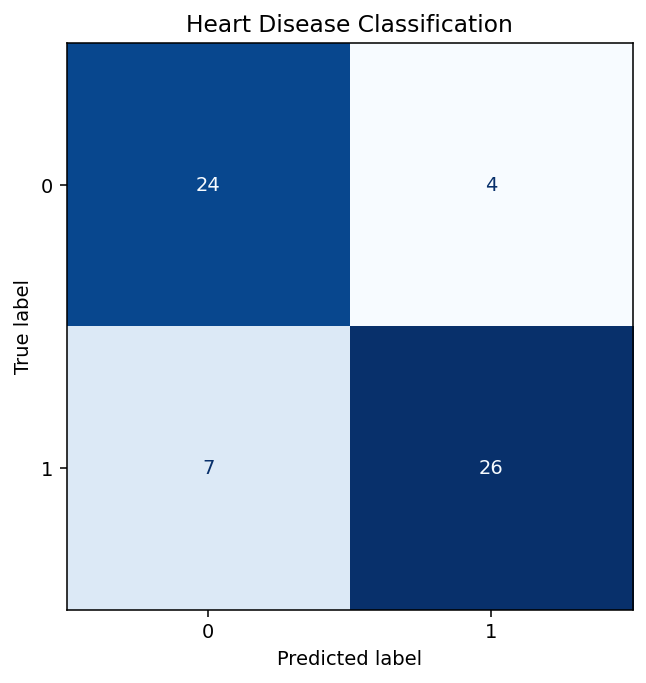

In [7]:
display(pd.DataFrame({"model_test": report["test_metrics"],
                      "dummy_test": report["baseline_metrics"],
                      "model_train": report["training_metrics"]}))
if "classification_report" in report:
    display(pd.DataFrame(report["classification_report"]).T)
output = ROOT / "reports" / PROJECT
save_result(result, output)
display(Image(filename=str(output / "diagnostics.png")))

## 5. Example predictions

These are held-out examples, not a production API. Inference accepts the cleaned feature schema produced by the loader. Inspect the source to understand encoding and feature exclusions.

In [8]:
examples = result["X_test"].iloc[:5]
display(examples)
display(pd.DataFrame({
    "actual": result["y_test"].iloc[:5].to_numpy(),
    "predicted": result["model"].predict(examples),
}))

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
24,61,0,0,145,307,0,0,146,1,1.0,1,0,3
59,59,1,3,170,288,0,0,159,0,0.2,1,0,3
257,67,1,0,120,229,0,0,129,1,2.6,1,2,3
54,67,1,2,152,212,0,0,150,0,0.8,1,0,3
40,61,0,0,130,330,0,0,169,0,0.0,2,0,2


,actual,predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,1


## 6. Interpretation and next experiment

Repeated records are removed before splitting. Patient identifiers and external validation are unavailable; this is not a diagnostic tool.

Use the confusion matrix or residuals to identify the most costly errors. Before client deployment, verify data rights and feature availability, evaluate an independent population, assess subgroup performance where relevant, and define monitoring and acceptance criteria.

[Project guide](../README.md) · [Portfolio](../../../README.md) · [Evaluation protocol](../../../docs/METHODOLOGY.md)